In [1]:
import math

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import socceraction.spadl.config as spadlcfg
from mplsoccer import Pitch


import matplotlib.pyplot as plt

# Data Import

In [2]:
# --- Config ---
DATA_PATH = Path().resolve().parent / "data" / "vaep_data" / "all_leagues_vaep.h5"
ACTION_TYPES = ["pass", "cross"]
SEASON_NAME = "2015/2016"
COMPETITIONS = ["Serie A", "La Liga", "Premier League", "1. Bundesliga", "Ligue 1"]
N_CLUSTERS = 50  # adjustable
TOP_K = 5

# --- Load data ---
with pd.HDFStore(DATA_PATH, mode="r") as store:
    df = store['vaep_data']

actiontype_map = dict(enumerate(spadlcfg.actiontypes))
df["action_type"] = df["type_id"].map(actiontype_map).fillna("unknown")


In [3]:
# --- Filter data ---
df = df[
    (df['action_type'].isin(ACTION_TYPES)) &
    (df['season_name'] == SEASON_NAME) &
    (df['competition_name'].isin(COMPETITIONS))
].copy()

In [4]:
# --- Feature engineering ---
# Option 1: start_x, start_y, dx, dy
df['dx'] = df['end_x_a0'] - df['start_x_a0']
df['dy'] = df['end_y_a0'] - df['start_y_a0']

# Option 2: start_x, start_y, length, cos, sin
df['length'] = np.sqrt(df['dx']**2 + df['dy']**2)
df['cos'] = df['dx'] / (df['length'] + 1e-8)
df['sin'] = df['dy'] / (df['length'] + 1e-8)

# Choose features for clustering
# FEATURES = ['start_x_a0', 'start_y_a0', 'dx', 'dy']
FEATURES = ['start_x_a0', 'start_y_a0', 'length', 'cos', 'sin']

# Utils

In [15]:
def compute_zscores(df):
    team_cluster = (
        df.groupby(["competition_name", "cluster"])
        .size()
        .reset_index(name="count")
    )
    team_total = df.groupby("competition_name").size().reset_index(name="total")
    dist = team_cluster.merge(team_total, on="competition_name")
    dist["prop"] = dist["count"] / dist["total"]
    league_avg = dist.groupby("cluster")["prop"].mean()
    league_std = dist.groupby("cluster")["prop"].std()
    dist["z"] = (
        (dist["prop"] - dist["cluster"].map(league_avg)) /
        (dist["cluster"].map(league_std) + 1e-6)
    )
    return dist

def representative_passes(df_cluster, scaler, n=30):
    """
    Select n passes closest to (most_central=True) or farthest from (most_central=False) the cluster centroid.
    """
    X = scaler.transform(df_cluster[FEATURES])
    centroid = X.mean(axis=0)
    dist = np.linalg.norm(X - centroid, axis=1)
    df_cluster = df_cluster.copy()
    df_cluster["dist"] = dist
    # return df_cluster.sort_values("dist", ascending=False).head(n)
    return df_cluster.sort_values("dist").head(n)



# from sklearn.metrics import pairwise_distances_argmin_min

# def representative_passes(df_cluster, scaler, n=30):
#     """
#     Select n passes closest to (most_central=True) or farthest from (most_central=False) the cluster centroid (medoids).
#     More robust than mean-based selection.
#     """
#     X = scaler.transform(df_cluster[FEATURES])
#     centroid = X.mean(axis=0)

#     _, dists = pairwise_distances_argmin_min([centroid], X)
#     df_cluster = df_cluster.copy()
#     df_cluster["dist"] = dists
#     return df_cluster.sort_values("dist", ascending=False).head(n)


### K-Means Clustering

In [16]:
from sklearn.cluster import KMeans

def run_clustering_kmeans(df, n_clusters=50, seed=123, n_init=30):
    scaler = MinMaxScaler()
    X = scaler.fit_transform(df[FEATURES])
    model = KMeans(n_clusters=n_clusters, random_state=seed, n_init=n_init)
    df = df.copy()
    df["cluster"] = model.fit_predict(X)
    return df, scaler, model

### K-Means Robust

In [17]:

def run_clustering_robust(df, n_clusters=50, seed=123, n_init=30):
    """
    Run KMeans clustering with improved robustness.
    - Uses k-means++ initialization
    - Increases n_init for stability
    - Logs and fixes the random seed
    Returns: clustered DataFrame, scaler, fitted KMeans model
    """
    scaler = MinMaxScaler()
    X = scaler.fit_transform(df[FEATURES])
    model = KMeans(
        n_clusters=n_clusters,
        random_state=seed,
        n_init=n_init,
        init="k-means++",
        verbose=0
    )
    df = df.copy()
    df["cluster"] = model.fit_predict(X)
    print(f"KMeans run with seed={seed}, n_init={n_init}, n_clusters={n_clusters}")
    return df, scaler, model

### DBscan, HDBscan

In [53]:
from sklearn.cluster import DBSCAN, HDBSCAN 

def run_clustering_hdbscan(df, min_cluster_size=100):
    """
    Run HDBSCAN clustering (density-based, robust to initialization).
    Returns: clustered DataFrame, scaler, fitted HDBSCAN model
    """
    scaler = MinMaxScaler()
    X = scaler.fit_transform(df[FEATURES])
    model = HDBSCAN(min_cluster_size=min_cluster_size, metric="euclidean", n_jobs=16)
    df = df.copy()
    df["cluster"] = model.fit_predict(X)
    print(f"HDBSCAN run with min_cluster_size={min_cluster_size}")
    return df, scaler, model



def run_clustering_dbscan(df, epsilon=.01, min_cluster_size=100):
    """
    Run DBSCAN clustering (density-based, robust to initialization).
    Returns: clustered DataFrame, scaler, fitted DBSCAN model
    """
    scaler = MinMaxScaler()
    X = scaler.fit_transform(df[FEATURES])
    model = DBSCAN(min_samples=min_cluster_size, metric="euclidean", n_jobs=16, eps=epsilon)
    df = df.copy()
    df["cluster"] = model.fit_predict(X)
    print(f"DBSCAN run with min_samples={min_cluster_size}")
    return df, scaler, model

### Viz

In [28]:
def plot_team(ax, df, dist, scaler, league, display_name=None, top_n=10, show_descriptions=False):
    """
    Plot team clusters and representative passes.
    representative_passes_fn: function to select representative passes (default: representative_passes)
    """
    team_df = df[df["competition_name"] == league].copy()       
    # --- handle z column naming ---
    z_col = "z_score" if "z_score" in dist.columns else "z"
    top_clusters = (
        dist[dist["competition_name"] == league]
        .sort_values(z_col, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    cmap = plt.colormaps["tab10"]
    # --- stable cluster-color mapping ---
    cluster_info = []
    for i, row in enumerate(top_clusters.itertuples()):
        cluster_info.append({
            "cluster": row.cluster,
            "color": cmap(i % 10),
            "idx": i + 1
        })
    # --- plot in reverse so #1 is on top ---
    for info in reversed(cluster_info):
        cluster_df = team_df[team_df["cluster"] == info["cluster"]]
        reps = representative_passes(cluster_df, scaler)
        for _, p in reps.iterrows():
            ax.arrow(
                p["start_x_a0"], p["start_y_a0"],
                p["dx"], p["dy"],
                head_width=1.2,
                head_length=2,
                linewidth=1.3,
                color=info["color"],
                alpha=0.4
            )
    # --- legend (original order) ---
    descriptions = [(c["idx"], c["color"]) for c in cluster_info]
    # --- title (with optional position) ---
    title = display_name if display_name is not None else league    
    ax.set_title(title, pad=6, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    y = -0.02
    if show_descriptions:
        for i, (idx, color) in enumerate(descriptions):
            ax.text(
                0.5,
                y - i * 0.06,
                f"➜ {idx}",
                transform=ax.transAxes,
                fontsize=9,
                color=color,
                ha="center",
                va="top"
            )
    else:
        x_positions = np.linspace(0.2, 0.8, len(descriptions))
        for x, (idx, color) in zip(x_positions, descriptions):
            ax.text(
                x,
                y,
                f"➜ {idx}",
                transform=ax.transAxes,
                fontsize=11,
                color=color,
                ha="center",
                va="top"
            )

In [35]:

def plot_grid(df, dist, scaler, title, n_cols=5, show_descriptions=False, top_n=10):
    TEAM_ORDER = ["Premier League", "La Liga", "Serie A", "1. Bundesliga", "Ligue 1"]
    pitch = Pitch(pitch_type="statsbomb", line_color="black")
    teams = [t for t in TEAM_ORDER if t in df["competition_name"].unique()]
    n_rows = math.ceil(len(teams) / n_cols)
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 4 * n_rows),
        gridspec_kw={'hspace': 0.08, 'wspace': 0.05},
    )
    axes = axes.flatten()
    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
        y=0.91
    )
    for i, team in enumerate(teams):
        pitch.draw(ax=axes[i])
        plot_team(
            axes[i],
            df,
            dist,
            scaler,
            team,
            display_name=f"{i+1}. {team}",
            show_descriptions=show_descriptions,
            top_n=top_n
        )
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout(rect=[0, 0.06, 1, 0.95])
    plt.show()


## Running

In [11]:
frac = 0.10  # 10% per game
df_sample = df.groupby('game_id', group_keys=False).apply(lambda x: x.sample(frac=frac, random_state=42))

C:\Users\anma10\AppData\Local\Temp\ipykernel_32948\877850849.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('game_id', group_keys=False).apply(lambda x: x.sample(frac=frac, random_state=42))


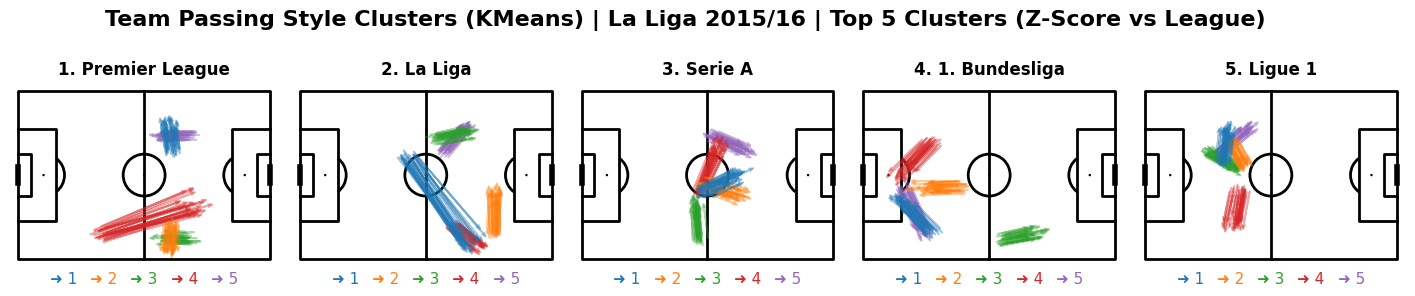

In [ ]:

# Run robust clustering
seed = 24
n_init = 10
top_n=5

df_all, scaler, model = run_clustering_kmeans(
    df, n_clusters=N_CLUSTERS, seed=seed, n_init=n_init
)

dist_all = compute_zscores(df_all)


plot_grid(
    df_all,
    dist_all,
    scaler,
    f"Team Passing Style Clusters (KMeans) | La Liga 2015/16 | Top {top_n} Clusters (Z-Score vs League)",
    top_n=top_n
)


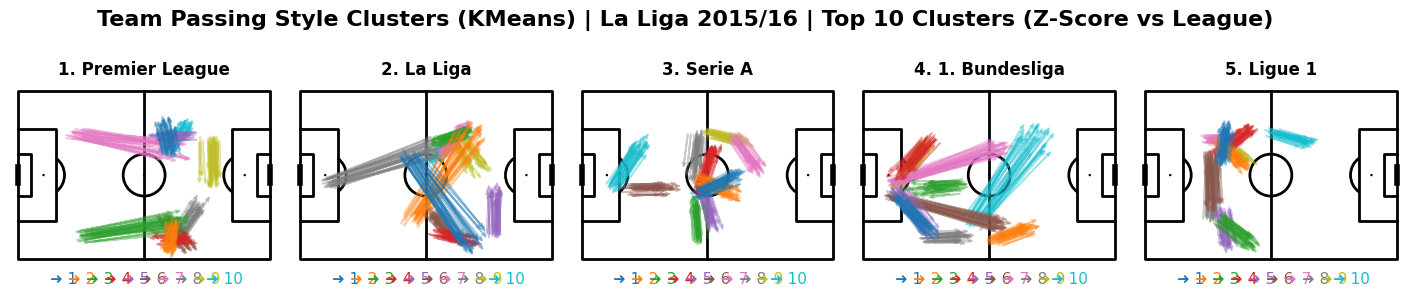

In [41]:
# Run robust clustering
seed = 24
n_init = 100
top_n=10

df_all, scaler, model = run_clustering_kmeans(
    df, n_clusters=N_CLUSTERS, seed=seed, n_init=n_init
)

dist_all = compute_zscores(df_all)


plot_grid(
    df_all,
    dist_all,
    scaler,
    f"Team Passing Style Clusters (KMeans) | La Liga 2015/16 | Top {top_n} Clusters (Z-Score vs League)",
    top_n=top_n
)

## Improving Clustering Robustness

This section demonstrates how to make cluster generation more robust and reproducible:



- Use KMeans++ initialization explicitly

- Increase `n_init` for more stable results

- Log and fix the random seed

- Evaluate cluster stability by running clustering multiple times

- Use medoids (most central points) for representative passes



Below is an improved version of the clustering and representative selection functions.

KMeans run with seed=24, n_init=100, n_clusters=50


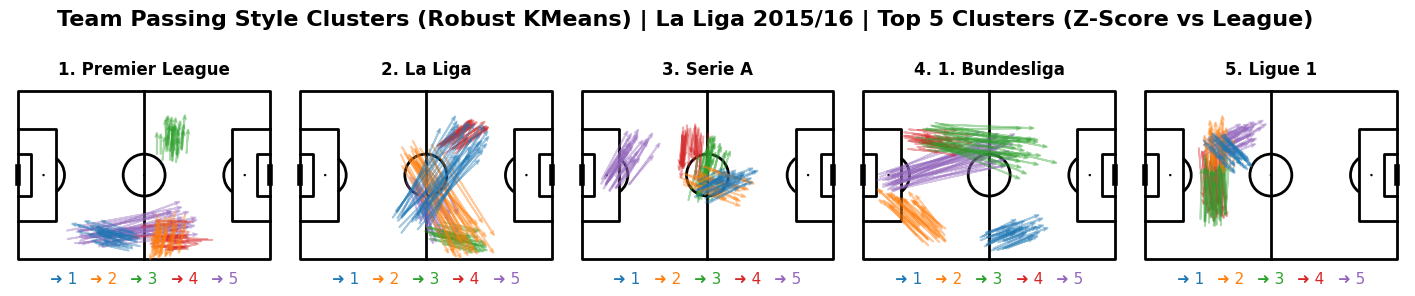

In [51]:
# Run robust clustering
robust_seed = 24
robust_n_init = 100
robust_n_clusters = 50
top_n=5


df_all_robust, scaler_robust, model_robust = run_clustering_robust(
    df_sample, n_clusters=robust_n_clusters, seed=robust_seed, n_init=robust_n_init
)

dist_all_robust = compute_zscores(df_all_robust)


plot_grid(
    df_all_robust,
    dist_all_robust,
    scaler_robust,
    f"Team Passing Style Clusters (Robust KMeans) | La Liga 2015/16 | Top {top_n} Clusters (Z-Score vs League)", 
    top_n=top_n
)


## Alternative: DBSCAN Clustering (Density-Based, Initialization-Independent)

DBSCAN is robust to initialization and can find clusters of arbitrary shape. It is scalable and does not require specifying the number of clusters. Below is a function using sklearn's DBSCAN.

c:\Users\anma10\PycharmProjects\transfer-learning-for-football-AI\venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


HDBSCAN run with min_cluster_size=100


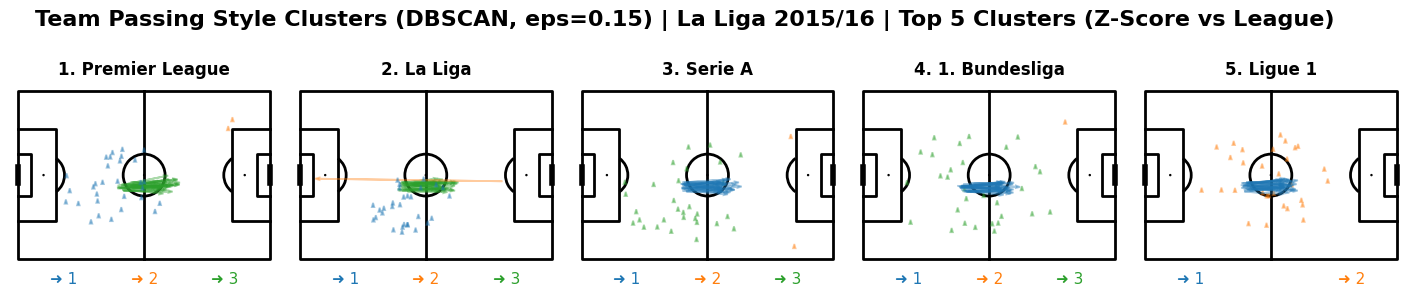

In [ ]:

dbscan_eps = 0.05  # You may need to tune this
min_samples = 100

df_all_dbscan, scaler_dbscan, model_dbscan = run_clustering_hdbscan(
    df, min_cluster_size=min_samples
)
dist_all_dbscan = compute_zscores(df_all_dbscan)

plot_grid(
    df_all_dbscan,
    dist_all_dbscan,
    scaler_dbscan,
    f"Team Passing Style Clusters (DBSCAN, eps={dbscan_eps}) | La Liga 2015/16 | Top 5 Clusters (Z-Score vs League)"
)


In [ ]:

dbscan_eps = 0.05  # You may need to tune this

df_all_dbscan_sub, scaler_dbscan_sub, model_dbscan_sub = run_clustering_dbscan(
    df_sub, min_cluster_size=10, epsilon=dbscan_eps
)
dist_all_dbscan_sub = compute_zscores(df_all_dbscan_sub)


plot_grid(
    df_all_dbscan_sub,
    dist_all_dbscan_sub,
    scaler_dbscan_sub,
    f"Team Passing Style Clusters (DBSCAN, eps={dbscan_eps}) | La Liga 2015/16 | Top 5 Clusters (Z-Score vs League)"
)
